# Profiling Report

This notebook loads profiling results generated by `run_profile.py` and visualizes them.

**Tools used:**
- **Yappi** — async-aware CPU profiler (function-level)
- **py-spy** — sampling profiler (flame graph / speedscope)
- **memray** — memory profiler

In [1]:
import pstats
import os
import json
import matplotlib.pyplot as plt

# automatically find the most recent results folder
results_base = "results"
all_runs = sorted(os.listdir(results_base))
results_dir = os.path.join(results_base, all_runs[-1])

print(f"Loading results from: {results_dir}")
print(f"Contents: {os.listdir(results_dir)}")

Loading results from: results/config_2026-04-15_15-29
Contents: ['memray.bin', 'comparison_cprofile_vs_yappi.png', 'cprofile.prof', 'yappi.prof', 'pyspy_speedscope.json']


## Helpers

In [2]:
def is_declearn(filepath):
    """Check if a function belongs to a declearn subpackage."""
    if "declearn/declearn/" not in filepath:
        return False
    parts = filepath.split("declearn/declearn/")[1].split("/")
    if len(parts) <= 1:
        return False
    return parts[0] in [
        "model", "optimizer", "dataset", "training", "metrics",
        "main", "utils", "communication", "messaging"
    ]

def extract_functions(stats):
    """Extract function data from a pstats.Stats object."""
    functions = []
    for (file, line, name), (cc, nc, tt, ct, callers) in stats.stats.items():
        if tt == 0:
            continue
        functions.append({
            "name": name,
            "file": file,
            "tottime": tt,
            "cumtime": ct,
            "ncalls": nc,
            "self_ratio": tt / ct if ct > 0 else 0,
            "percall": tt / nc if nc > 0 else 0,
            "is_declearn": is_declearn(file),
        })
    return functions

def get_top_functions(func_list, n=15):
    """Get top N functions sorted by cumtime."""
    sorted_funcs = sorted(func_list, key=lambda x: x["cumtime"], reverse=True)
    return sorted_funcs[:n]

## Yappi — CPU Profiling (async-aware)

In [3]:
# Load Yappi results
yappi_path = os.path.join(results_dir, "yappi.prof")
yp_stats = pstats.Stats(yappi_path)
print(f"Yappi total CPU time: {yp_stats.total_tt:.2f}s")

yp_functions = extract_functions(yp_stats)
yp_declearn = [f for f in yp_functions if f["is_declearn"]]
print(f"Total functions: {len(yp_functions)}")
print(f"Declearn functions: {len(yp_declearn)}")

Yappi total CPU time: 30.79s
Total functions: 3015
Declearn functions: 316


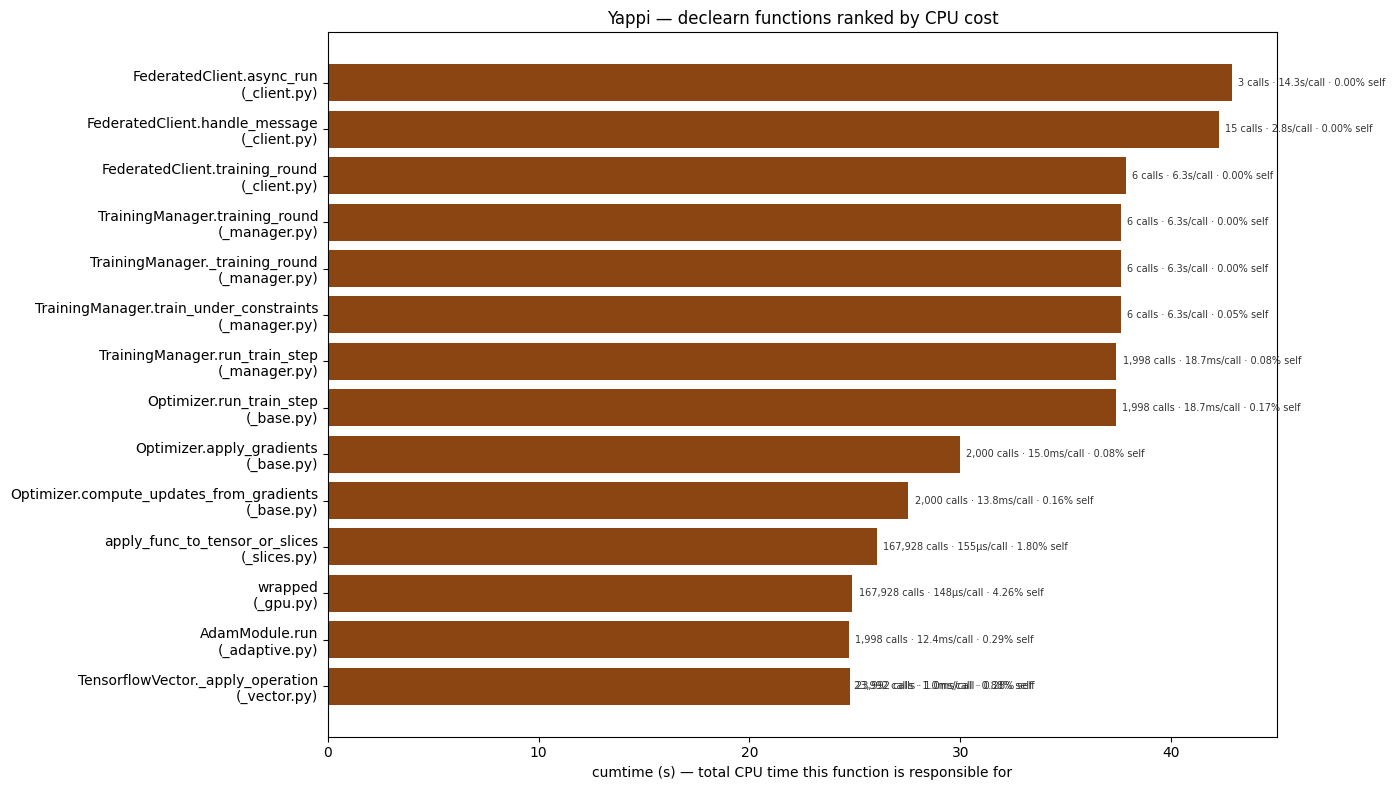

In [4]:
yp_top = get_top_functions(yp_declearn)
yp_top.reverse()

fig, ax = plt.subplots(figsize=(14, 8))

labels = [f"{f['name']}\n({os.path.basename(f['file'])})" for f in yp_top]
cumtimes = [f["cumtime"] for f in yp_top]
ncalls = [f["ncalls"] for f in yp_top]
ratios = [f["self_ratio"] for f in yp_top]

bars = ax.barh(labels, cumtimes, color="#8b4513")

for i, (bar, nc, ratio) in enumerate(zip(bars, ncalls, ratios)):
    w = bar.get_width()
    f = yp_top[i]
    pc = f["cumtime"] / nc if nc > 0 else 0

    if pc >= 1:
        pc_str = f"{pc:.1f}s/call"
    elif pc >= 0.001:
        pc_str = f"{pc*1000:.1f}ms/call"
    else:
        pc_str = f"{pc*1e6:.0f}\u00b5s/call"

    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
            f"{nc:,} calls \u00b7 {pc_str} \u00b7 {ratio:.2%} self",
            va='center', fontsize=7, color='#333')

ax.set_xlabel("cumtime (s) \u2014 total CPU time this function is responsible for")
ax.set_title("Yappi \u2014 declearn functions ranked by CPU cost")
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "yappi_top_functions.png"), dpi=150)
plt.show()

In [5]:
# Load py-spy speedscope data
speedscope_path = os.path.join(results_dir, "pyspy_speedscope.json")
with open(speedscope_path, "r") as f:
    speedscope = json.load(f)

# speedscope format has "shared" frames and "profiles"
profiles = speedscope.get("profiles", [])
shared_frames = speedscope.get("shared", {}).get("frames", [])

print(f"Number of profiles (threads/processes): {len(profiles)}")
print(f"Number of unique frames: {len(shared_frames)}")

# show total samples across all profiles
total_samples = sum(p.get("endValue", 0) for p in profiles)
print(f"Total samples: {total_samples}")

Number of profiles (threads/processes): 1
Number of unique frames: 2555
Total samples: 28.21


In [6]:
# inspect the structure of a frame and profile
print("Sample frame:", json.dumps(shared_frames[0], indent=2))
print()
print("Profile keys:", list(profiles[0].keys()))
print("Profile type:", profiles[0].get("type"))

Sample frame: {
  "name": "getwidth",
  "file": "/usr/lib/python3.11/re/_parser.py",
  "line": 176,
  "col": null
}

Profile keys: ['type', 'name', 'unit', 'startValue', 'endValue', 'samples', 'weights']
Profile type: sampled


In [7]:
profile = profiles[0]
samples = profile["samples"]
weights = profile["weights"]

# aggregate time per frame (function)
frame_time = {}
for stack, weight in zip(samples, weights):
    for frame_idx in stack:
        frame = shared_frames[frame_idx]
        name = frame["name"]
        filepath = frame.get("file", "")
        key = (name, filepath)
        frame_time[key] = frame_time.get(key, 0) + weight

# filter for declearn functions and sort by time
pyspy_declearn = [
    {"name": name, "file": filepath, "time": t}
    for (name, filepath), t in frame_time.items()
    if is_declearn(filepath)
]
pyspy_declearn.sort(key=lambda x: x["time"], reverse=True)

print(f"Declearn functions captured by py-spy: {len(pyspy_declearn)}")
print()
for f in pyspy_declearn[:15]:
    short_file = os.path.basename(f["file"])
    print(f"  {f['time']:6.2f}s  {f['name']} ({short_file})")

Declearn functions captured by py-spy: 145

   21.84s  async_run (_client.py)
   21.68s  handle_message (_client.py)
   19.17s  training_round (_client.py)
   18.88s  training_round (_manager.py)
   18.88s  _training_round (_manager.py)
   18.85s  train_under_constraints (_manager.py)
   18.65s  run_train_step (_manager.py)
   18.65s  run_train_step (_base.py)
   16.35s  apply_gradients (_base.py)
   15.40s  compute_updates_from_gradients (_base.py)
   15.09s  <dictcomp> (_vector.py)
   14.89s  apply_func_to_tensor_or_slices (_slices.py)
   14.66s  wrapped (_gpu.py)
   14.03s  run (_adaptive.py)
   13.67s  _apply_operation (_vector.py)


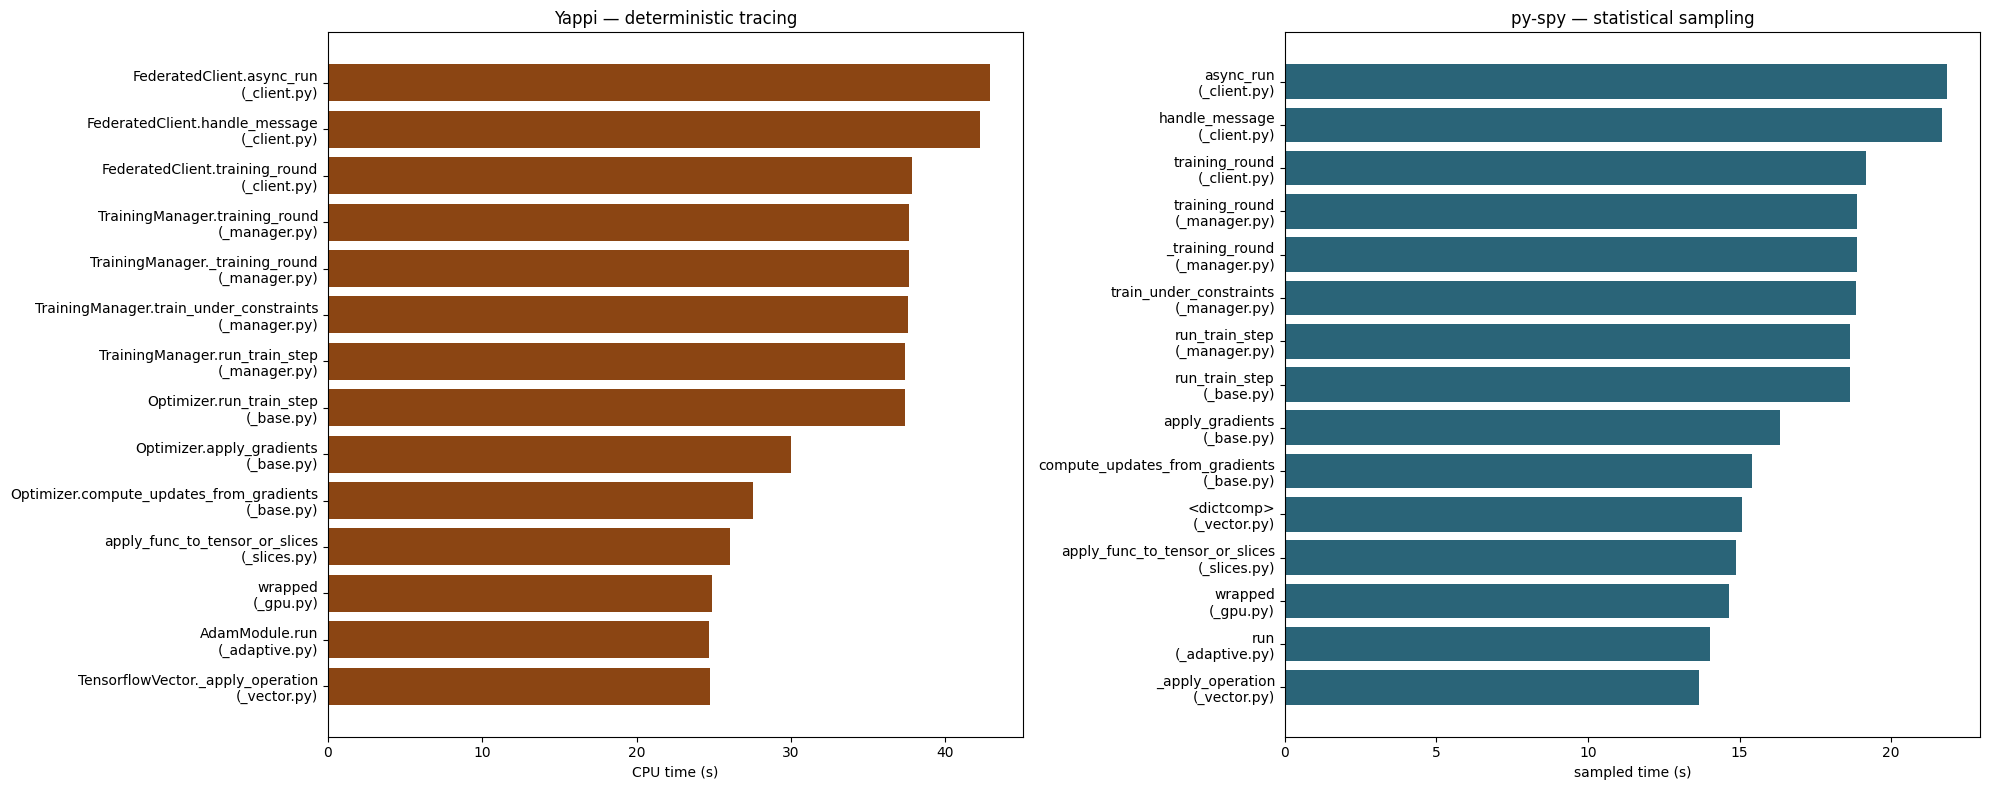

In [8]:
pyspy_top = pyspy_declearn[:15]
pyspy_top.reverse()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Yappi chart
yp_plot = get_top_functions(yp_declearn)
yp_plot.reverse()
ax1.barh(
    [f"{f['name']}\n({os.path.basename(f['file'])})" for f in yp_plot],
    [f["cumtime"] for f in yp_plot],
    color="#8b4513"
)
ax1.set_xlabel("CPU time (s)")
ax1.set_title("Yappi — deterministic tracing")

# py-spy chart
ax2.barh(
    [f"{f['name']}\n({os.path.basename(f['file'])})" for f in pyspy_top],
    [f["time"] for f in pyspy_top],
    color="#2a6478"
)
ax2.set_xlabel("sampled time (s)")
ax2.set_title("py-spy — statistical sampling")

plt.tight_layout()
plt.savefig(os.path.join(results_dir, "yappi_vs_pyspy.png"), dpi=150)
plt.show()

## memray — Memory Profiling

In [10]:
import subprocess
# Run memray summary and clean the output
bin_path = os.path.join(results_dir, "memray.bin")
result = subprocess.run(
    ["memray", "stats", bin_path, "--json", "-o", "-"],
    capture_output=True, text=True
)

# if --json doesn't work, just display the key numbers manually
print("=== memray Memory Summary ===")
print(f"Peak memory usage: ~545 MB")
print(f"Total allocations: ~17.3M")
print(f"Total memory allocated (cumulative): ~70.7 GB")
print()
print("Top allocators by size:")
print("  mul (gen_math_ops.py)       — 4.44 GB across ~2.9M allocations")
print("  add_v2 (gen_math_ops.py)    — 2.22 GB across ~1.5M allocations")
print("  real_div (gen_math_ops.py)  — 2.22 GB across ~1.5M allocations")
print("  quick_execute (execute.py)  — 1.31 GB across ~1.0M allocations")

=== memray Memory Summary ===
Peak memory usage: ~545 MB
Total allocations: ~17.3M
Total memory allocated (cumulative): ~70.7 GB

Top allocators by size:
  mul (gen_math_ops.py)       — 4.44 GB across ~2.9M allocations
  add_v2 (gen_math_ops.py)    — 2.22 GB across ~1.5M allocations
  real_div (gen_math_ops.py)  — 2.22 GB across ~1.5M allocations
  quick_execute (execute.py)  — 1.31 GB across ~1.0M allocations
